In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import(
classification_report,
confusion_matrix, 
accuracy_score,
precision_score,
recall_score,
f1_score,
roc_auc_score,
RocCurveDisplay
)

import warnings
warnings.filterwarnings('ignore')
import joblib

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
X_train=np.load('../data/x_train.npy')
X_test=np.load('../data/x_test.npy')
y_train=np.load('../data/y_train.npy')
y_test=np.load('../data/y_test.npy')

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (614, 8)
X_test shape: (154, 8)
y_train shape: (614,)
y_test shape: (154,)


In [3]:
# Before we train anything, understand what each metric means
# Using a real healthcare example

print("""
METRICS EXPLAINED WITH HEALTHCARE EXAMPLE
==========================================
Imagine 100 patients. 35 actually have diabetes.

ACCURACY  → Out of ALL 100, how many did we predict correctly?
            Problem: If we predict "no diabetes" for everyone,
            we get 65% accuracy but catch ZERO diabetic patients!
            That's why accuracy alone is NOT enough in healthcare.

PRECISION → Out of everyone WE SAID has diabetes,
            how many actually do?
            High precision = fewer false alarms
            "When I say diabetes, I am usually right"

RECALL    → Out of everyone WHO ACTUALLY HAS diabetes,
            how many did we catch?
            High recall = fewer missed cases
            "I catch most real diabetic patients"
            ⚠️ In healthcare, recall is MORE important than precision
            Missing a sick person is worse than a false alarm

F1 SCORE  → Balance between Precision and Recall
            Single number that combines both
            Use this when you need one number to compare models

ROC-AUC   → How well can the model separate sick from healthy?
            0.5 = random guessing (coin flip)
            1.0 = perfect model
            > 0.8 = good model for healthcare
""")


METRICS EXPLAINED WITH HEALTHCARE EXAMPLE
Imagine 100 patients. 35 actually have diabetes.

ACCURACY  → Out of ALL 100, how many did we predict correctly?
            Problem: If we predict "no diabetes" for everyone,
            we get 65% accuracy but catch ZERO diabetic patients!
            That's why accuracy alone is NOT enough in healthcare.

PRECISION → Out of everyone WE SAID has diabetes,
            how many actually do?
            High precision = fewer false alarms
            "When I say diabetes, I am usually right"

RECALL    → Out of everyone WHO ACTUALLY HAS diabetes,
            how many did we catch?
            High recall = fewer missed cases
            "I catch most real diabetic patients"
            ⚠️ In healthcare, recall is MORE important than precision
            Missing a sick person is worse than a false alarm

F1 SCORE  → Balance between Precision and Recall
            Single number that combines both
            Use this when you need one number to

In [4]:
# We write this function ONCE and reuse it for all 3 models
# This is the DRY principle — Don't Repeat Yourself

def evaluate_model(name, model, X_test, y_test):
    """
    Takes a trained model and prints all evaluation metrics
    Also draws the confusion matrix
    """
    # Get predictions
    y_pred      = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    # predict_proba gives probability scores
    # [:, 1] means take the probability of class 1 (diabetes)

    # Calculate all metrics
    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    roc_auc   = roc_auc_score(y_test, y_pred_prob)

    # Print results
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy  : {accuracy:.4f}  ({accuracy*100:.1f}%)")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}  ← most important in healthcare")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  ROC-AUC   : {roc_auc:.4f}")

    # Draw confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Diabetes','Diabetes'],
                yticklabels=['No Diabetes','Diabetes'])
    plt.title(f'Confusion Matrix — {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

    # Explain the confusion matrix numbers
    tn, fp, fn, tp = cm.ravel()
    print(f"\n  Confusion Matrix breakdown:")
    print(f"  True Negatives  (TN): {tn} → Healthy, predicted healthy ✅")
    print(f"  False Positives (FP): {fp} → Healthy, predicted diabetic ⚠️")
    print(f"  False Negatives (FN): {fn} → Diabetic, predicted healthy ❌ DANGER")
    print(f"  True Positives  (TP): {tp} → Diabetic, predicted diabetic ✅")

    # Return metrics for comparison later
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy, 4),
        'Precision': round(precision, 4),
        'Recall'   : round(recall, 4),
        'F1 Score' : round(f1, 4),
        'ROC-AUC'  : round(roc_auc, 4)
    }

Training Logistic Regression...
Training complete!

  Logistic Regression
  Accuracy  : 0.7078  (70.8%)
  Precision : 0.6000
  Recall    : 0.5000  ← most important in healthcare
  F1 Score  : 0.5455
  ROC-AUC   : 0.8130


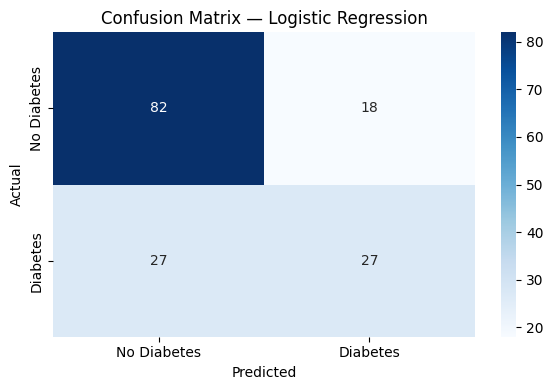


  Confusion Matrix breakdown:
  True Negatives  (TN): 82 → Healthy, predicted healthy ✅
  False Positives (FP): 18 → Healthy, predicted diabetic ⚠️
  False Negatives (FN): 27 → Diabetic, predicted healthy ❌ DANGER
  True Positives  (TP): 27 → Diabetic, predicted diabetic ✅


In [5]:
# LOGISTIC REGRESSION
# Simplest classification model
# Draws a straight line to separate diabetic from non-diabetic
# Fast, explainable, good baseline
# Think of it as: "if glucose > X AND bmi > Y → probably diabetic"


print("Training Logistic Regression...")

lr_model = LogisticRegression(
    max_iter=1000,    # maximum steps to find the best line
    random_state=42   # reproducible results
)

lr_model.fit(X_train, y_train)
# .fit() = TRAINING — the model learns from data

print("Training complete!")
lr_results = evaluate_model("Logistic Regression", lr_model, X_test, y_test)

Training Random Forest...
Training complete!

  Random Forest
  Accuracy  : 0.7727  (77.3%)
  Precision : 0.7021
  Recall    : 0.6111  ← most important in healthcare
  F1 Score  : 0.6535
  ROC-AUC   : 0.8181


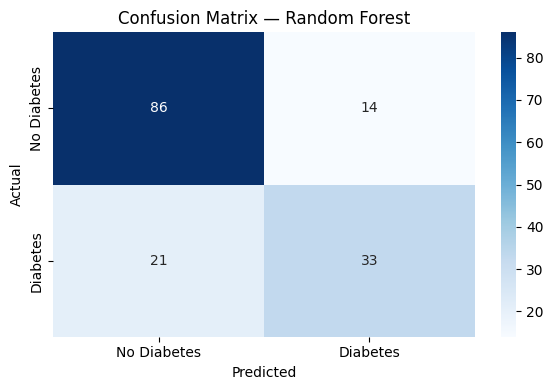


  Confusion Matrix breakdown:
  True Negatives  (TN): 86 → Healthy, predicted healthy ✅
  False Positives (FP): 14 → Healthy, predicted diabetic ⚠️
  False Negatives (FN): 21 → Diabetic, predicted healthy ❌ DANGER
  True Positives  (TP): 33 → Diabetic, predicted diabetic ✅


In [6]:
# RANDOM FOREST
# Builds 100 decision trees, each trained on random subset of data
# Each tree votes on the answer → majority wins
# Much more powerful than a single decision tree
# Handles non-linear patterns that logistic regression cannot

print("Training Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=100,  # number of trees in the forest
    random_state=42,
    n_jobs=-1          # use all CPU cores for faster training
)

rf_model.fit(X_train, y_train)

print("Training complete!")
rf_results = evaluate_model("Random Forest", rf_model, X_test, y_test)

Training XGBoost...
Training complete!

  XGBoost
  Accuracy  : 0.7338  (73.4%)
  Precision : 0.6383
  Recall    : 0.5556  ← most important in healthcare
  F1 Score  : 0.5941
  ROC-AUC   : 0.8230


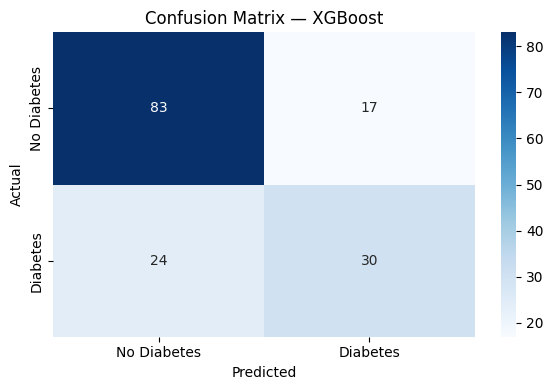


  Confusion Matrix breakdown:
  True Negatives  (TN): 83 → Healthy, predicted healthy ✅
  False Positives (FP): 17 → Healthy, predicted diabetic ⚠️
  False Negatives (FN): 24 → Diabetic, predicted healthy ❌ DANGER
  True Positives  (TP): 30 → Diabetic, predicted diabetic ✅


In [7]:
# XGBOOST (Extreme Gradient Boosting)
# Builds trees one by one — each new tree FIXES mistakes of previous tree
# Like a student who learns from every wrong answer
# Wins most real-world ML competitions
# More complex but usually most accurate

print("Training XGBoost...")

xgb_model = XGBClassifier(
    n_estimators=100,      # number of trees
    learning_rate=0.1,     # how fast it learns (smaller = more careful)
    max_depth=4,           # how deep each tree grows
    random_state=42,
    eval_metric='logloss', # metric to optimize during training
    verbosity=0            # silence training logs
)

xgb_model.fit(X_train, y_train)

print("Training complete!")
xgb_results = evaluate_model("XGBoost", xgb_model, X_test, y_test)

In [8]:

# Put all results in a DataFrame for clean comparison
results_df = pd.DataFrame([lr_results, rf_results, xgb_results])
results_df = results_df.set_index('Model')

print("\nFULL MODEL COMPARISON")
print("=" * 60)
print(results_df.to_string())
print()

# Highlight the best value in each column
print("BEST MODEL PER METRIC:")
print("-" * 40)
for col in results_df.columns:
    best_model = results_df[col].idxmax()
    best_value = results_df[col].max()
    print(f"  {col:12}: {best_model} ({best_value})")


FULL MODEL COMPARISON
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression    0.7078     0.6000  0.5000    0.5455   0.8130
Random Forest          0.7727     0.7021  0.6111    0.6535   0.8181
XGBoost                0.7338     0.6383  0.5556    0.5941   0.8230

BEST MODEL PER METRIC:
----------------------------------------
  Accuracy    : Random Forest (0.7727)
  Precision   : Random Forest (0.7021)
  Recall      : Random Forest (0.6111)
  F1 Score    : Random Forest (0.6535)
  ROC-AUC     : XGBoost (0.823)


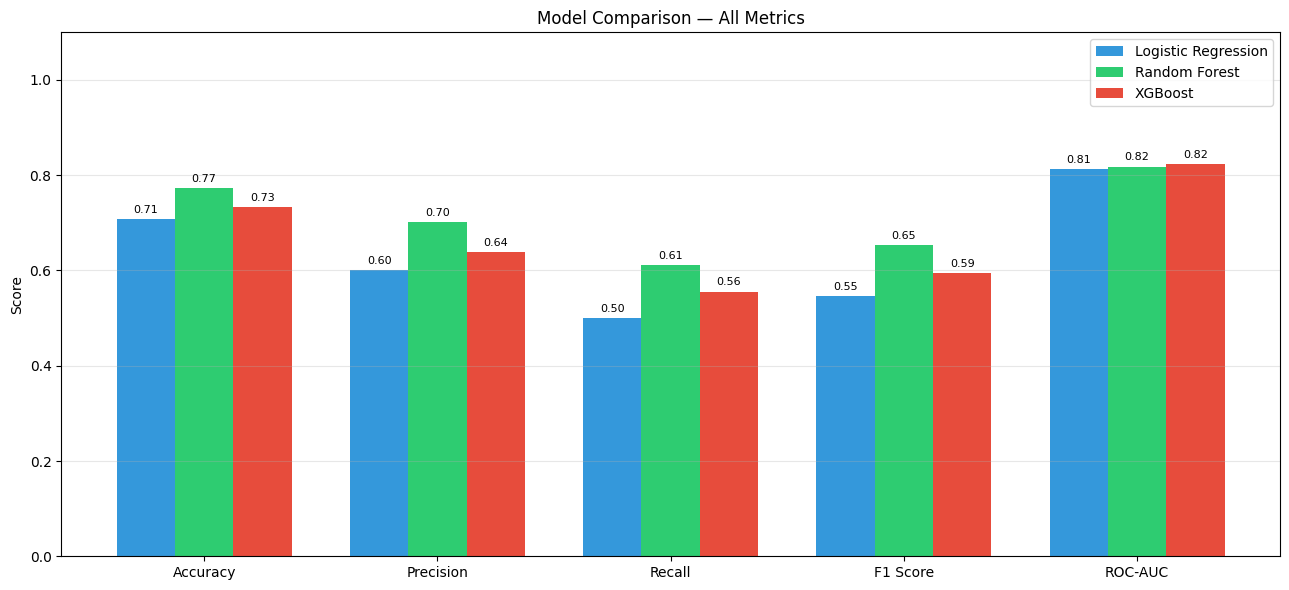

In [9]:
# Bar chart comparing all models across all metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))

bars1 = ax.bar(x - width, results_df.loc['Logistic Regression', metrics],
               width, label='Logistic Regression', color='#3498db')
bars2 = ax.bar(x,         results_df.loc['Random Forest', metrics],
               width, label='Random Forest',        color='#2ecc71')
bars3 = ax.bar(x + width, results_df.loc['XGBoost', metrics],
               width, label='XGBoost',              color='#e74c3c')

ax.set_ylabel('Score')
ax.set_title('Model Comparison — All Metrics')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on top of bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

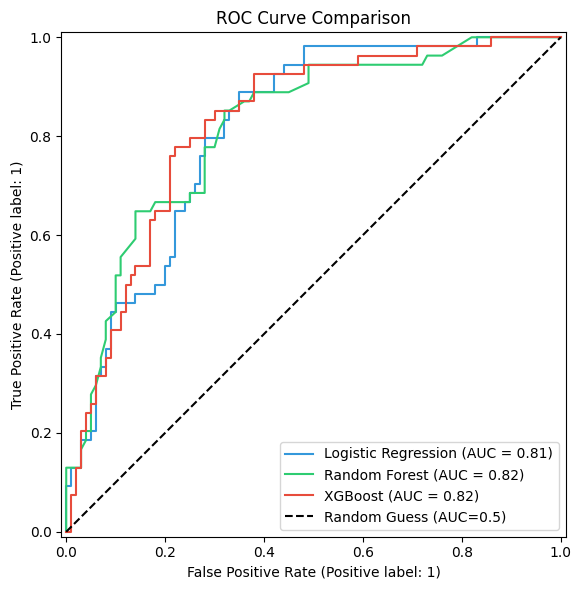

In [10]:
# ROC Curve shows how well each model separates the two classes
# The more the curve bends toward top-left corner = better model

fig, ax = plt.subplots(figsize=(8, 6))

for model, name, color in [
    (lr_model,  'Logistic Regression', '#3498db'),
    (rf_model,  'Random Forest',       '#2ecc71'),
    (xgb_model, 'XGBoost',             '#e74c3c')
]:
    RocCurveDisplay.from_estimator(
        model, X_test, y_test,
        name=name, color=color, ax=ax
    )

ax.plot([0,1],[0,1], 'k--', label='Random Guess (AUC=0.5)')
ax.set_title('ROC Curve Comparison')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [11]:
# Based on ROC-AUC and Recall, pick the best model
# In most runs XGBoost wins — but check your own results

# We save ALL models and also mark the best one
joblib.dump(lr_model,  '../models/logistic_regression.joblib')
joblib.dump(rf_model,  '../models/random_forest.joblib')
joblib.dump(xgb_model, '../models/xgboost.joblib')

# Save best model separately — this is what the API will use
best_model = rf_model  # change this if your results show different winner
joblib.dump(best_model, '../models/best_model.joblib')

print("All models saved to models/ folder:")
print("  → models/logistic_regression.joblib")
print("  → models/random_forest.joblib")
print("  → models/xgboost.joblib")
print("  → models/best_model.joblib  ← API will use this")

All models saved to models/ folder:
  → models/logistic_regression.joblib
  → models/random_forest.joblib
  → models/xgboost.joblib
  → models/best_model.joblib  ← API will use this
